In [81]:
import pandas as pd
import scanpy as sc
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

#====================================================================================================
# Define gene sets for scoring
#====================================================================================================

gene_sets = {
    "glycolysis_genes": ["ALDOA", "ENO2", "HK1", "HK2", "PFKFB3", "PGK1", "PKM"], # Glycolytic Genes

    "tca_genes": ["ATP5F1A", "ATP5F1C", "ATP6V1B1", "ATP6V1H", "CYCS", "DLD", "NDUFAB1", "PDHA1", "PDHB", "PDX1", "SDHA", "SDHB"], # TCA genes

    "acid_genes": ["CA9", "CA12", "LDHA", "SLC16A1"], # Acid genes

    "activity_genes":["ALDOA", "ENO2", "HK1", "HK2", "PFKFB3", "PGK1", "PKM", 
                      "ATP5F1A", "ATP5F1C", "ATP6V1B1", "ATP6V1H", "CYCS", "DLD", "NDUFAB1", "PDHA1", "PDHB", "PDX1", "SDHA", "SDHB", 
                      "CA9", "CA12", "LDHA", "SLC16A1"], # Composite glycolysis, tca, acid genes
    
    "vascular_genes": ['PECAM1','EPAS1','HSPG2','PLVAP','SHANK3']
}

#====================================================================================================
# load data and preprocess for use by squidpy
#====================================================================================================

adata = sc.read_h5ad('Annotated_Xenium_UPC.h5ad')
samples = {}

for i, sample_id in enumerate(adata.obs['sample'].unique(), start=1):
    sample = adata[adata.obs['sample'] == sample_id].copy()
    for name, genes in gene_sets.items():
        sc.tl.score_genes(sample, gene_list=genes, score_name=f'{name}_score', layer='counts_raw')
    sample.uns["spatial"] = {
        "library_id": {
            "images": {"hires": None, "lowres": None},
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": 1.0
            }
        }
    }
    sample.obs["library_id"] = "library_id"
    samples[sample_id] = sample

print(f'Sample IDs: {list(samples.keys())}')

Sample IDs: ['1050-3t-mid', '1064UPC', '1103UPC']


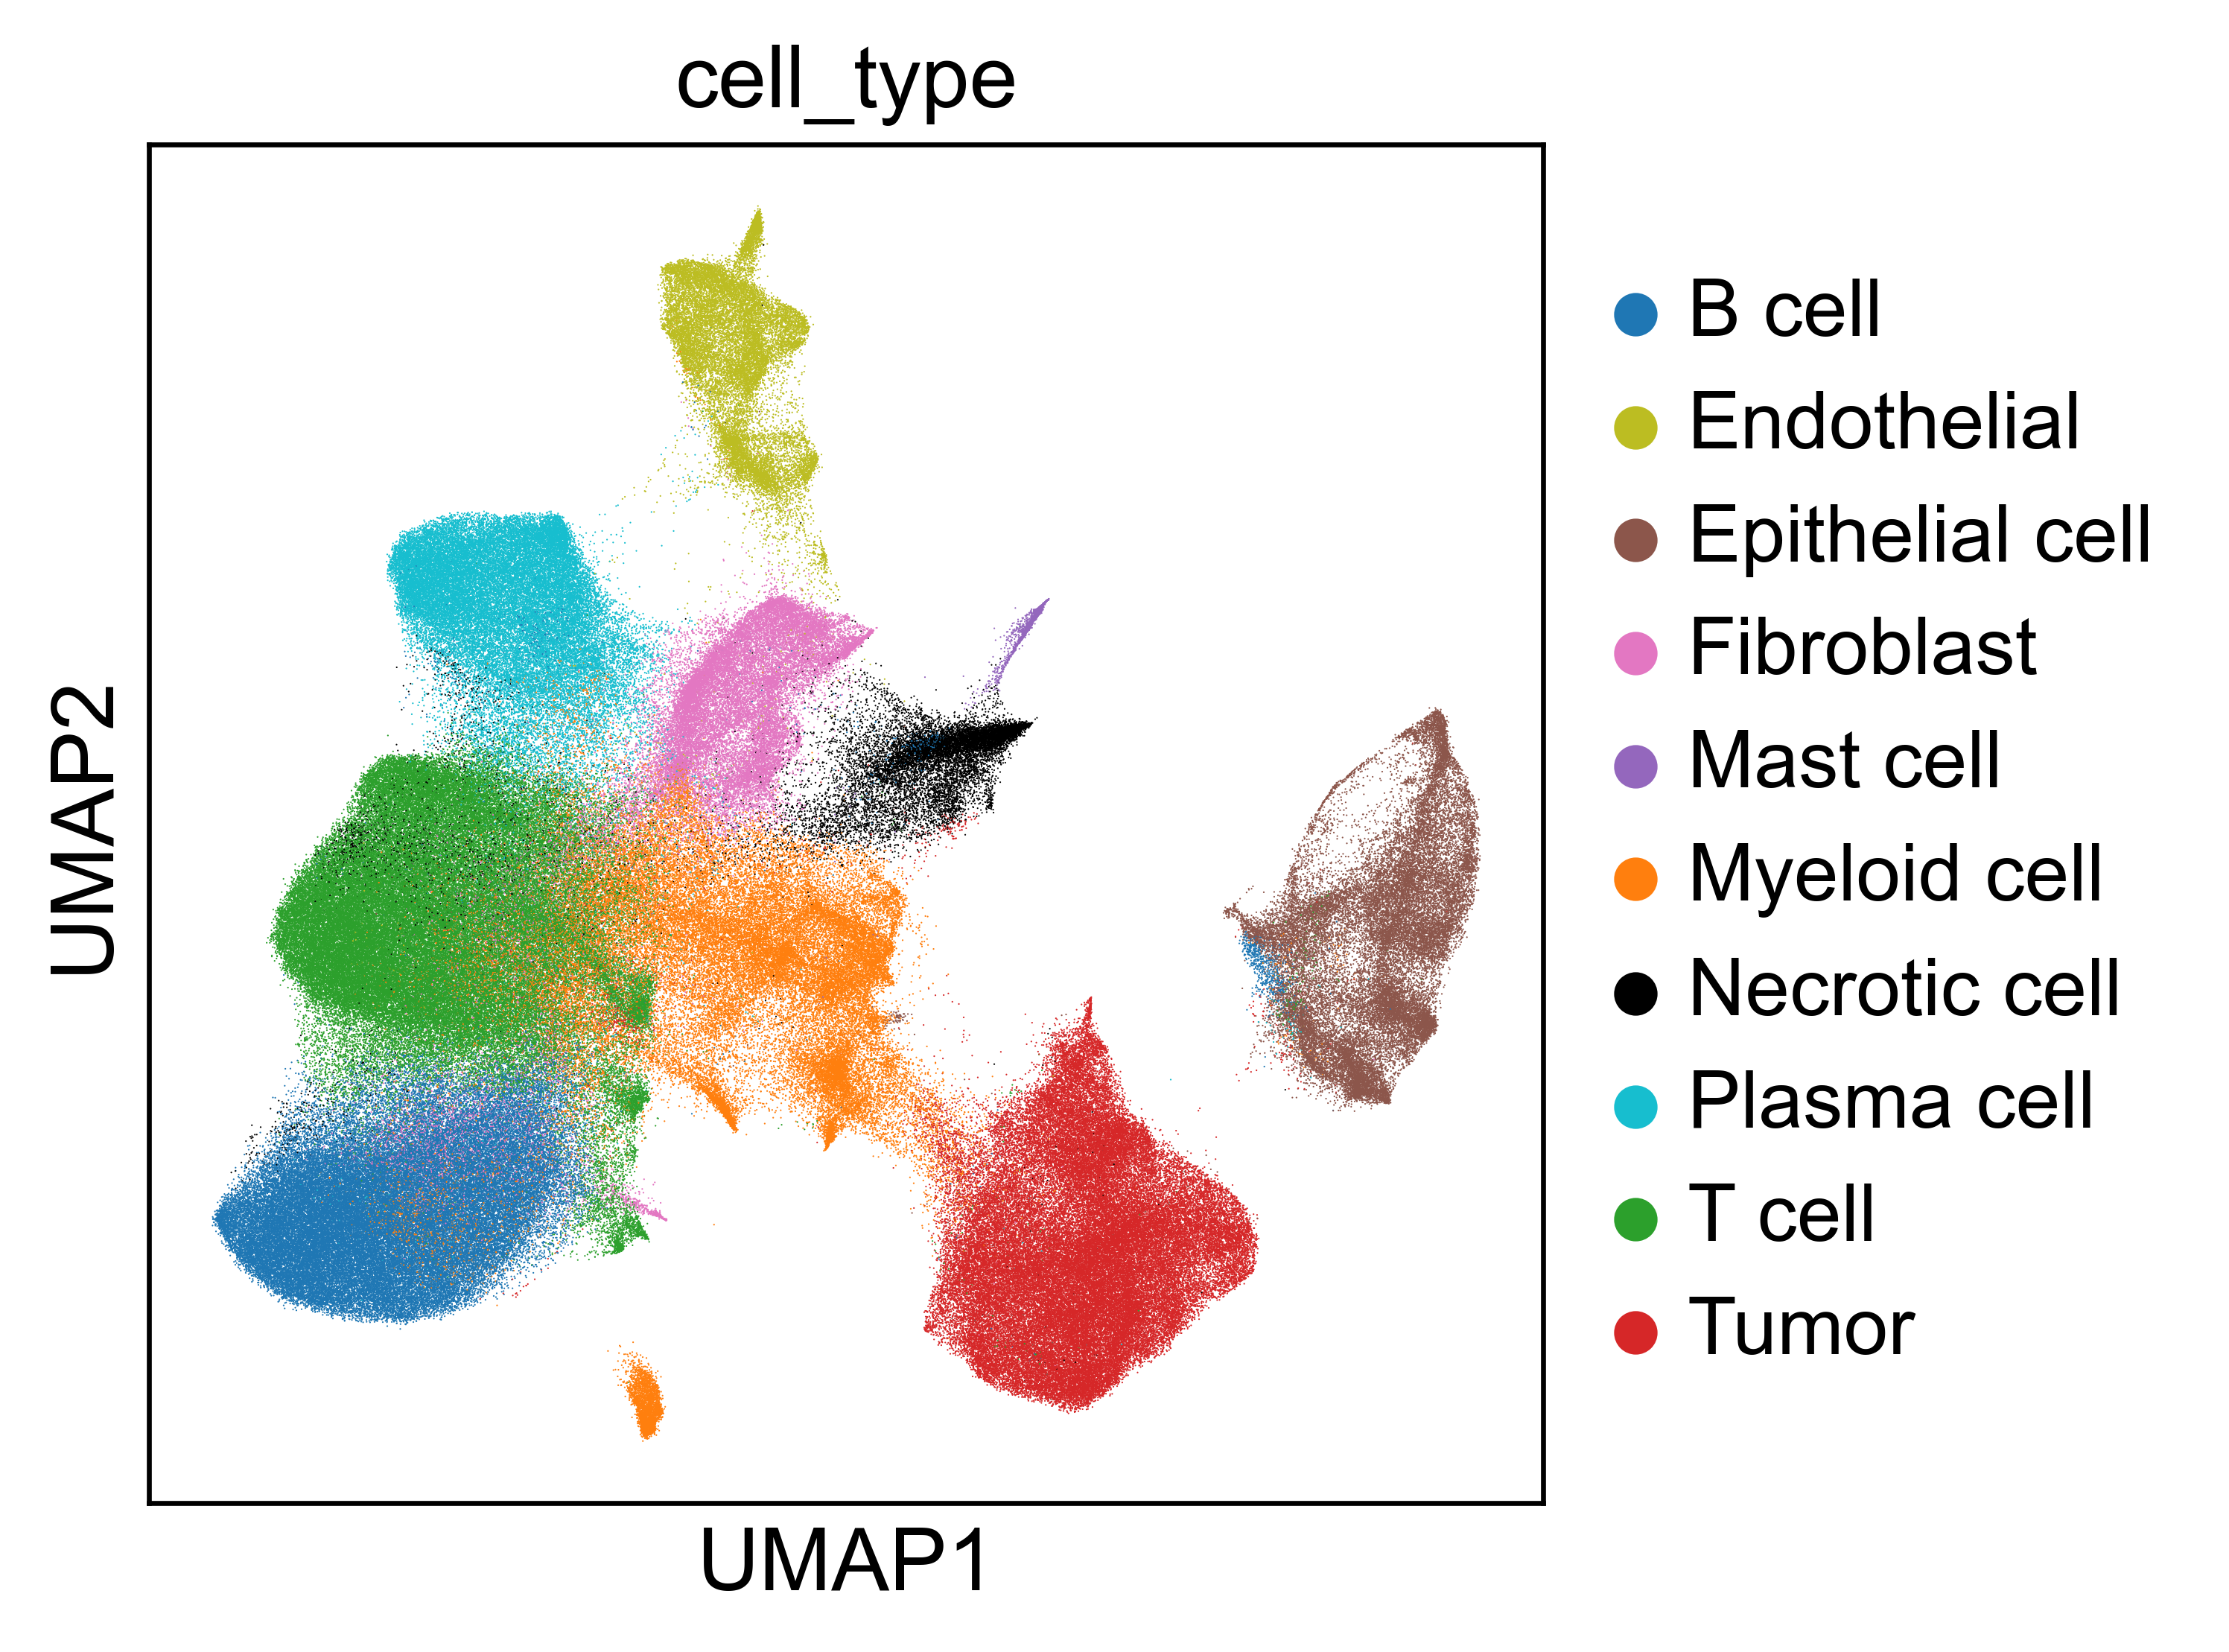

In [195]:
sc.settings.set_figure_params(dpi=300, facecolor='white')
sc.pl.umap(adata,color='cell_type')

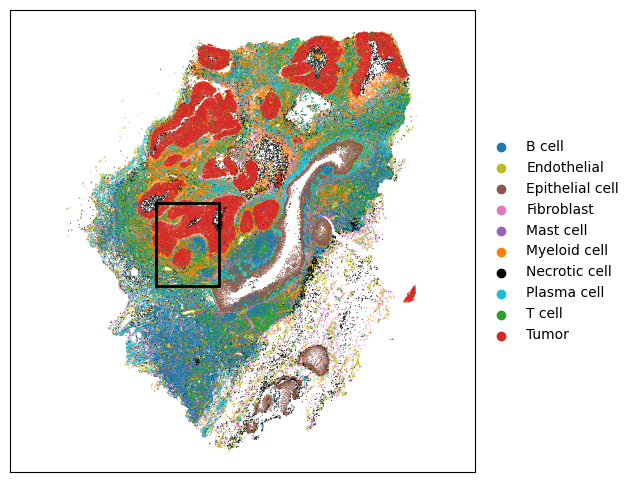

In [158]:
#====================================================================================================
# Select ROI for sample of interest
#====================================================================================================

# Rectangle parameters: 1103UPC
sample_id = samples['1103UPC']
x, y = 1700, 3100           # bottom-left corner
width, height = 900, 1200   # dimensions

# Rectangle parameters: 1064UPC
#sample_id = samples['1064UPC']
#x, y = 5350, 1700           # bottom-left corner
#width, height = 1200, 900   # dimensions

# Rectangle parameters: 1050-3t-mid
#sample_id = samples['1050-3t-mid']
#x, y = 1300, 1700           # bottom-left corner
#width, height = 1200, 900   # dimensions


# Plot spatial data
fig, ax = plt.subplots(figsize=(6, 6))
sq.pl.spatial_scatter(
    sample_id,
    color='cell_type',
    size=14,
    ax=ax,
    img=False,
    figsize=(10,10)
)

# Draw rectangle on spatial plot
rect = patches.Rectangle(
    (x, y), width, height,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)
ax.add_patch(rect)
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

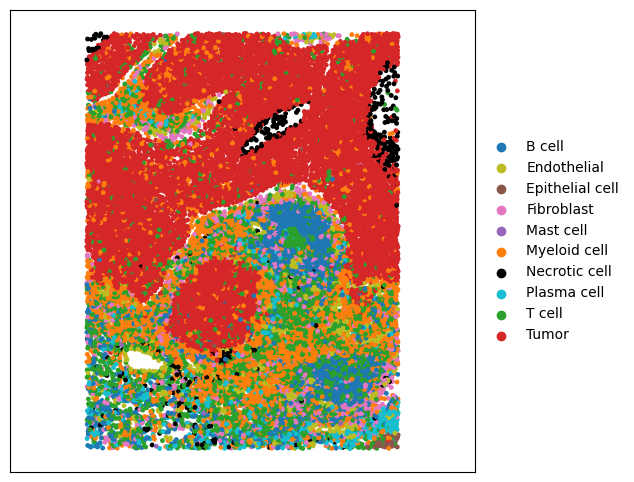

In [159]:
#====================================================================================================
# Visualize ROI
#====================================================================================================
spatial = sample_id.obsm["spatial"]
x_min, x_max = x, x + width
y_min, y_max = y, y + height
in_rect = (
    (spatial[:, 0] >= x_min) & (spatial[:, 0] <= x_max) &
    (spatial[:, 1] >= y_min) & (spatial[:, 1] <= y_max)
)
sample_roi = sample_id[in_rect].copy()

# Plot spatial data
fig, ax = plt.subplots(figsize=(6, 6))
sq.pl.spatial_scatter(
    sample_roi,
    color='cell_type',
    size=14,
    ax=ax,
    img=False,
    figsize=(10,10)
)
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [160]:
#====================================================================================================
# Score Smoothing
#====================================================================================================
n_neighbors = 100 # Number of neighbors for smoothing; a higher number means more smoothing

sq.gr.spatial_neighbors(sample_roi, coord_type="generic", n_neighs=n_neighbors)
adj = sample_roi.obsp["spatial_connectivities"]
for score_col in sample_roi.obs.columns:
    if score_col.endswith("_score"):
        # Smooth the score
        smoothed = adj.dot(sample_roi.obs[score_col].values)
        smoothed = smoothed / adj.sum(axis=1).A1  # normalize
            
        # Save back to obs with a new name
        sample_roi.obs[f"{score_col}_smoothed"] = smoothed 
        print(f"{score_col}_smoothed min: {sample_roi.obs[score_col].min()}, max: {sample_roi.obs[score_col].max()}")

glycolysis_genes_score_smoothed min: -0.7985714285714287, max: 4.317619047619048
tca_genes_score_smoothed min: -0.402059925093633, max: 1.543820224719101
acid_genes_score_smoothed min: -0.61, max: 6.245
activity_genes_score_smoothed min: -0.17234907725993118, max: 2.5233030966531125
vascular_genes_score_smoothed min: -0.876, max: 9.088000000000001


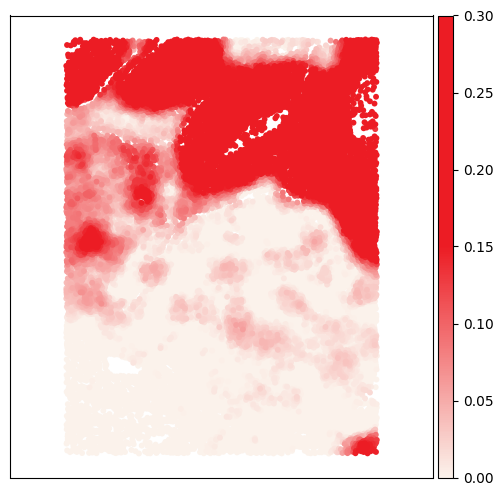

In [167]:
#====================================================================================================
# Visualize Scores
#====================================================================================================

colors = ["#fbf2eb",'#ec1c24',"#ec1c24"]  # Set color range for activity
score_interest = 'acid_genes_score_smoothed'



custom_cmap = LinearSegmentedColormap.from_list(score_interest+"_hot", colors, N=256)
sample_roi = sample_roi[sample_roi.obs.sort_values(score_interest, ascending=True).index]
# Plot spatial data
fig, ax = plt.subplots(figsize=(6, 6))
sq.pl.spatial_scatter(
    sample_roi,
    color=score_interest,
    size=17,
    cmap=custom_cmap,
    ax=ax,
    img=False,
    vmin=0,
    vmax=0.3,
    figsize=(10,10)
)
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [168]:
#====================================================================================================
# Read in and smooth ICG
#====================================================================================================

mipc = pd.read_csv('Z:/WillHartnett/Xenium UPC/1103UPC_ICG/1103UPC_mean_intensity_per_cell.csv').set_index('cell_id')
sample_roi.obs_names = [cell.split('_')[0] for cell in sample_roi.obs_names]
mipc = mipc.loc[sample_roi.obs_names]
sample_roi.obs = sample_roi.obs.join(mipc)
sample_roi.obs["mean_intensity_smoothed"] = adj.dot(sample_roi.obs['mean_intensity'].values) / adj.sum(axis=1).A1  # normalize

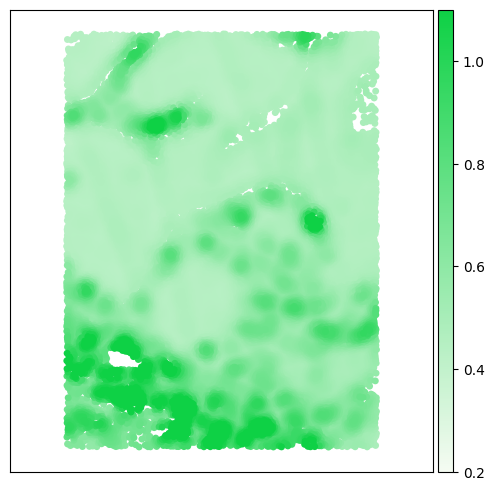

In [169]:
#====================================================================================================
# Visualize ICG
#====================================================================================================

colors = ["#f5fbf2","#0ed145"]  



custom_cmap = LinearSegmentedColormap.from_list("mean_intensity_hot", colors, N=256)
sample_roi = sample_roi[sample_roi.obs.sort_values("mean_intensity", ascending=True).index]
fig, ax = plt.subplots(figsize=(6, 6))
sq.pl.spatial_scatter(
    sample_roi,
    color='mean_intensity',
    size=20,
    cmap=custom_cmap,
    ax=ax,
    img=False,
    vmin=0.2,
    vmax=1.1,
    figsize=(10,10)
)
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [170]:
masking = pd.read_csv('1103UPC_Mask_groupings.csv')
masking.columns = ['index','mask_identity','x','y']

In [171]:
spatial_coords = sample_roi.obsm["spatial"]  # shape: (n_cells, 2)
spatial_df = pd.DataFrame(spatial_coords, columns=["x", "y"])

# Merge based on coordinates — safest if you round to reduce float matching errors
masking["x_rounded"] = masking['x'].round(2)
masking["y_rounded"] = masking['y'].round(2)
spatial_df["x_rounded"] = spatial_df["x"].round(2)
spatial_df["y_rounded"] = spatial_df["y"].round(2)

spatial_df = spatial_df.merge(masking[["mask_identity", "x_rounded", "y_rounded"]],
                               on=["x_rounded", "y_rounded"],
                               how="left")

In [172]:
sample_roi.obs['mask_identity'] = spatial_df['mask_identity'].values

C:\Users\s236927\AppData\Local\Temp\ipykernel_29172\1530301696.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sample_roi.obs['mask_identity'] = spatial_df['mask_identity'].values


In [173]:
sample_roi_4 = sample_roi

C:\Users\s236927\AppData\Local\Temp\ipykernel_29172\2471873437.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


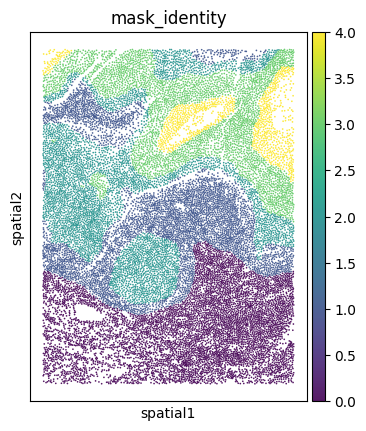

In [187]:
sc.pl.spatial(
    sample_roi_4,                     # your AnnData object
    color='mask_identity',   # e.g., 'leiden', 'cell_type', or 'predicted_label'
    spot_size=4.0,             # adjust based on resolution
    cmap='viridis',            # for continuous values
    size=1.5,                  # for Xenium datasets, you may use size over spot_size
    alpha=0.9,                 # transparency
    show=True
)

In [ ]:
mean_intensity_area = pd.Series([
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([0,1])].obs['mean_intensity'].mean(),
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([2,3,4])].obs['mean_intensity'].mean(),
    sample_roi_2[sample_roi_2.obs['mask_identity'].isin([3,4])].obs['mean_intensity'].mean(),
    sample_roi_2[sample_roi_2.obs['mask_identity'].isin([0,1,2])].obs['mean_intensity'].mean(),
    #sample_roi_4[sample_roi_4.obs['mask_identity'].isin([2,3,4])].obs['mean_intensity'].mean(),
    #sample_roi_4[sample_roi_4.obs['mask_identity'].isin([0,1])].obs['mean_intensity'].mean(),
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([0])].obs['mean_intensity'].mean(),
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([1])].obs['mean_intensity'].mean(),
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([2])].obs['mean_intensity'].mean(),
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([3])].obs['mean_intensity'].mean(),
    #sample_roi_1[sample_roi_1.obs['mask_identity'].isin([4])].obs['mean_intensity'].mean(),
],
#index=['0','1','2','3','4'])
index=['Tumor','Stroma','Tumor','Stroma','Tumor','Stroma',])
print(sample_roi_2[sample_roi_2.obs['mask_identity'].isin([3,4])].obs['mean_intensity'].mean())
print(sample_roi_2[sample_roi_2.obs['mask_identity'].isin([0,1,2])].obs['mean_intensity'].mean())

0.4934319761858152
0.9060614146737598


In [204]:
print(sample_roi_1[sample_roi_1.obs['mask_identity'].isin([0,1])].obs['mean_intensity'].mean())
print(sample_roi_1[sample_roi_1.obs['mask_identity'].isin([2,3,4])].obs['mean_intensity'].mean())
print(sample_roi_2[sample_roi_2.obs['mask_identity'].isin([3,4])].obs['mean_intensity'].mean())
print(sample_roi_2[sample_roi_2.obs['mask_identity'].isin([0,1,2])].obs['mean_intensity'].mean())
print(sample_roi_4[sample_roi_4.obs['mask_identity'].isin([2,3,4])].obs['mean_intensity'].mean())
print(sample_roi_4[sample_roi_4.obs['mask_identity'].isin([0,1])].obs['mean_intensity'].mean())

0.42590692662744134
2.3456213544118434
0.4934319761858152
0.9060614146737598
0.46651966369092185
0.6840270883699293


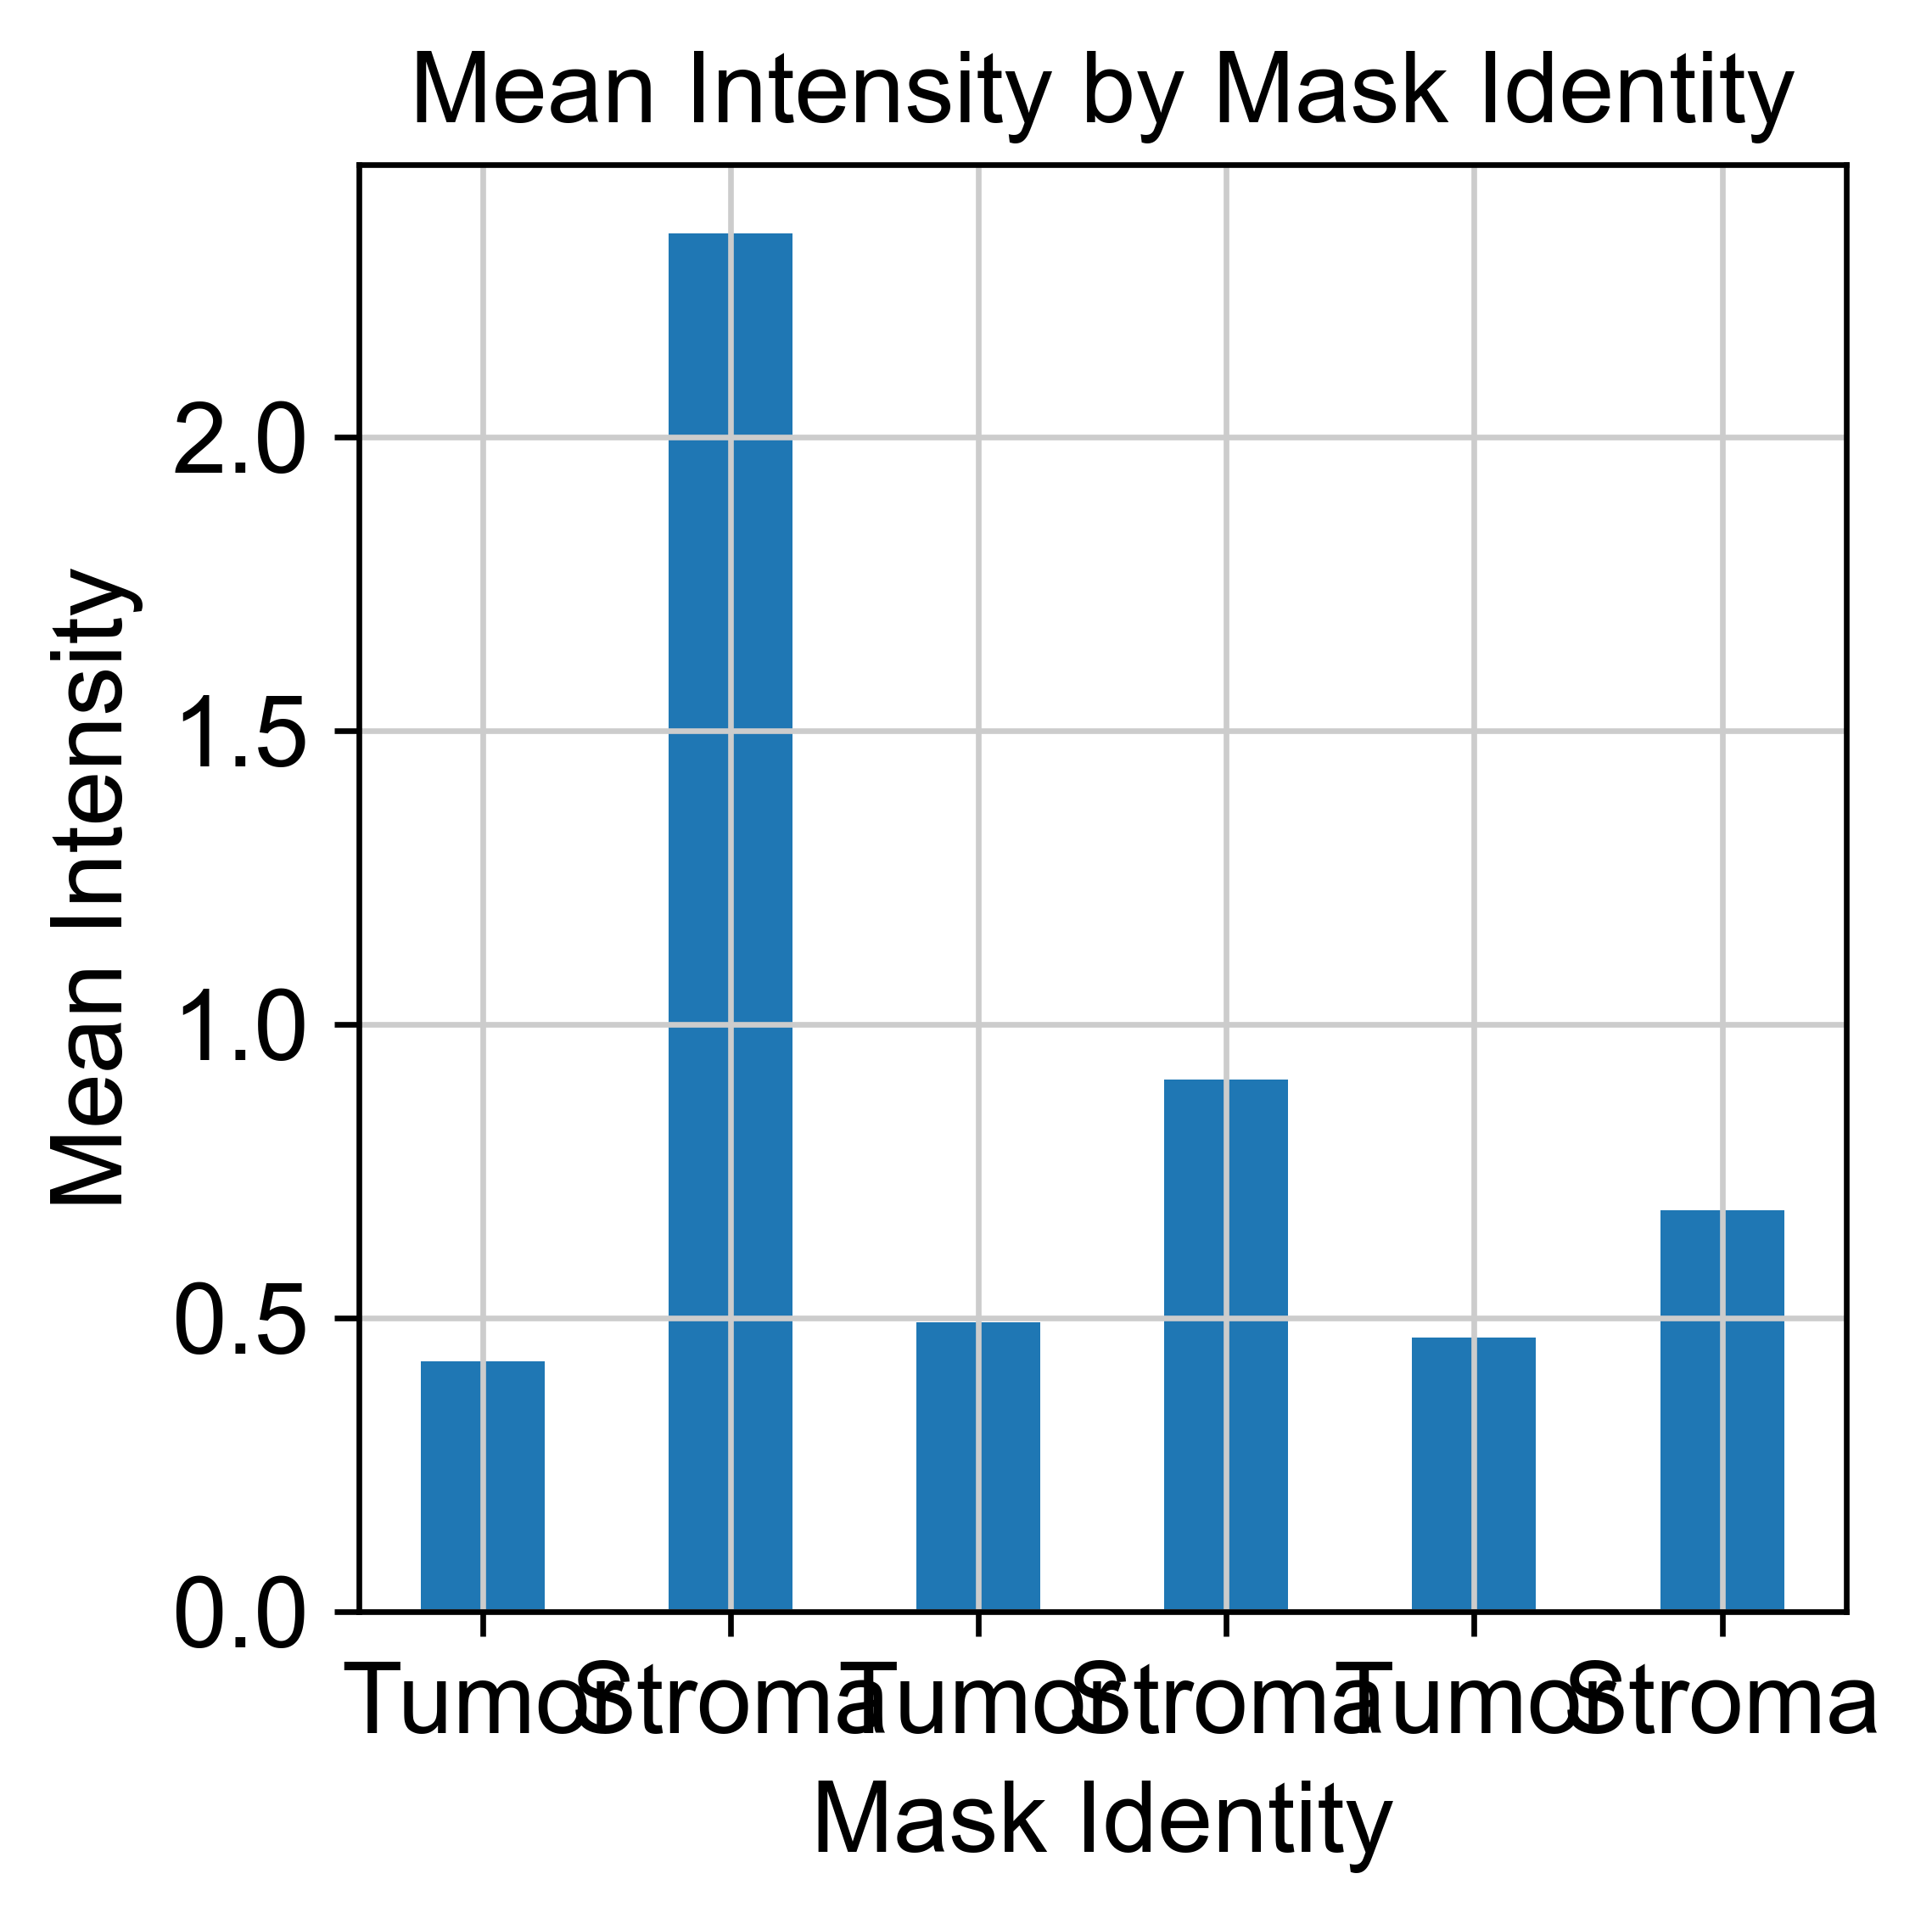

In [202]:
mean_intensity_area.plot(kind='bar')
plt.title("Mean Intensity by Mask Identity")
plt.xlabel("Mask Identity")
plt.ylabel("Mean Intensity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()